In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
if os.path.basename(os.getcwd()) == 'notes': os.chdir('..')
print('工作目录:', os.getcwd())

工作目录: d:\github\prediction


In [2]:
# ============================================================
# 从 NetCDF 读取 #0 站点 (1141A 普陀) → DataFrame → 80/15/5 分割 → 预处理
# 先分割再插值, 杜绝边界数据泄漏
# ============================================================
import netCDF4 as nc

def load_station(nc_path, idx=0):
    """从 NetCDF 读取指定站点, 转为带 datetime 索引的 DataFrame"""
    f = nc.Dataset(nc_path)
    t = f.variables['time'][:]
    dt = pd.Timestamp(f.variables['time'].units.split('since ')[1]) + pd.to_timedelta(t, unit='h')
    # 变量映射: NetCDF → 旧列名
    pm25 = f.variables['PM2.5'][:, idx]
    temp = f.variables['t2m'][:, idx] - 273.15       # K → °C
    dewp = f.variables['d2m'][:, idx] - 273.15       # K → °C
    pres = f.variables['sp'][:, idx] / 100.0         # Pa → hPa
    tp   = f.variables['tp'][:, idx] * 1000.0        # m → mm
    u, v = f.variables['u100'][:, idx], f.variables['v100'][:, idx]
    iws  = np.sqrt(u**2 + v**2)                       # 风速 m/s
    # 风向分类: cv(静风)/NE/SE/SW/NW
    wdir = np.degrees(np.arctan2(-u, -v)) % 360
    cbwd = np.where(iws < 0.5, 'cv',
           np.where(wdir < 90, 'NE', np.where(wdir < 180, 'SE',
           np.where(wdir < 270, 'SW', 'NW')))).astype('<U2')
    # 湿度: Magnus 公式
    a, b = 17.625, 243.04
    humi = np.clip(100 * np.exp(a*dewp/(dewp+b+1e-10)) / np.exp(a*temp/(temp+b+1e-10)), 0, 100)
    f.close()
    df = pd.DataFrame({'PM_Jingan': pm25, 'PM_US Post': pm25, 'PM_Xuhui': pm25,
        'DEWP': dewp, 'HUMI': humi, 'PRES': pres, 'TEMP': temp,
        'cbwd': cbwd, 'Iws': iws, 'precipitation': tp, 'Iprec': np.cumsum(tp)}, index=dt)
    df.index.name = 'datetime'
    return df.resample('1h').first()  # 补齐完整 1h 时间轴

def split_and_preprocess(df, ratios=(0.80, 0.15, 0.05)):
    """按时间分割 → 各子集独立预处理 (无泄漏) → 返回 train/val/test"""
    n = len(df); n1 = int(n * ratios[0]); n2 = int(n * sum(ratios[:2]))
    subs = []
    for raw in [df.iloc[:n1], df.iloc[n1:n2], df.iloc[n2:]]:
        d = raw.copy()
        d['pm_ave'] = d[['PM_Jingan','PM_US Post','PM_Xuhui']].mean(axis=1)
        d['pm_ave'] = d['pm_ave'].interpolate(method='time', limit=168).ffill().bfill()
        subs.append(d)
    return subs  # df_tr, df_va, df_te

df_raw = load_station('data3/dataset_yrd.nc', idx=0)
df_tr, df_va, df_te = split_and_preprocess(df_raw)
print(f'训练 {len(df_tr)} | 验证 {len(df_va)} | 测试 {len(df_te)}')
print(f'pm_ave 范围: {df_tr.pm_ave.min():.1f} ~ {df_tr.pm_ave.max():.1f} ug/m3')

# 基线模型: 训练集每小时历史均值
hourly_baseline = df_tr.groupby(df_tr.index.hour)['pm_ave'].mean()

训练 56102 | 验证 10519 | 测试 3507
pm_ave 范围: 1.0 ~ 241.0 ug/m3


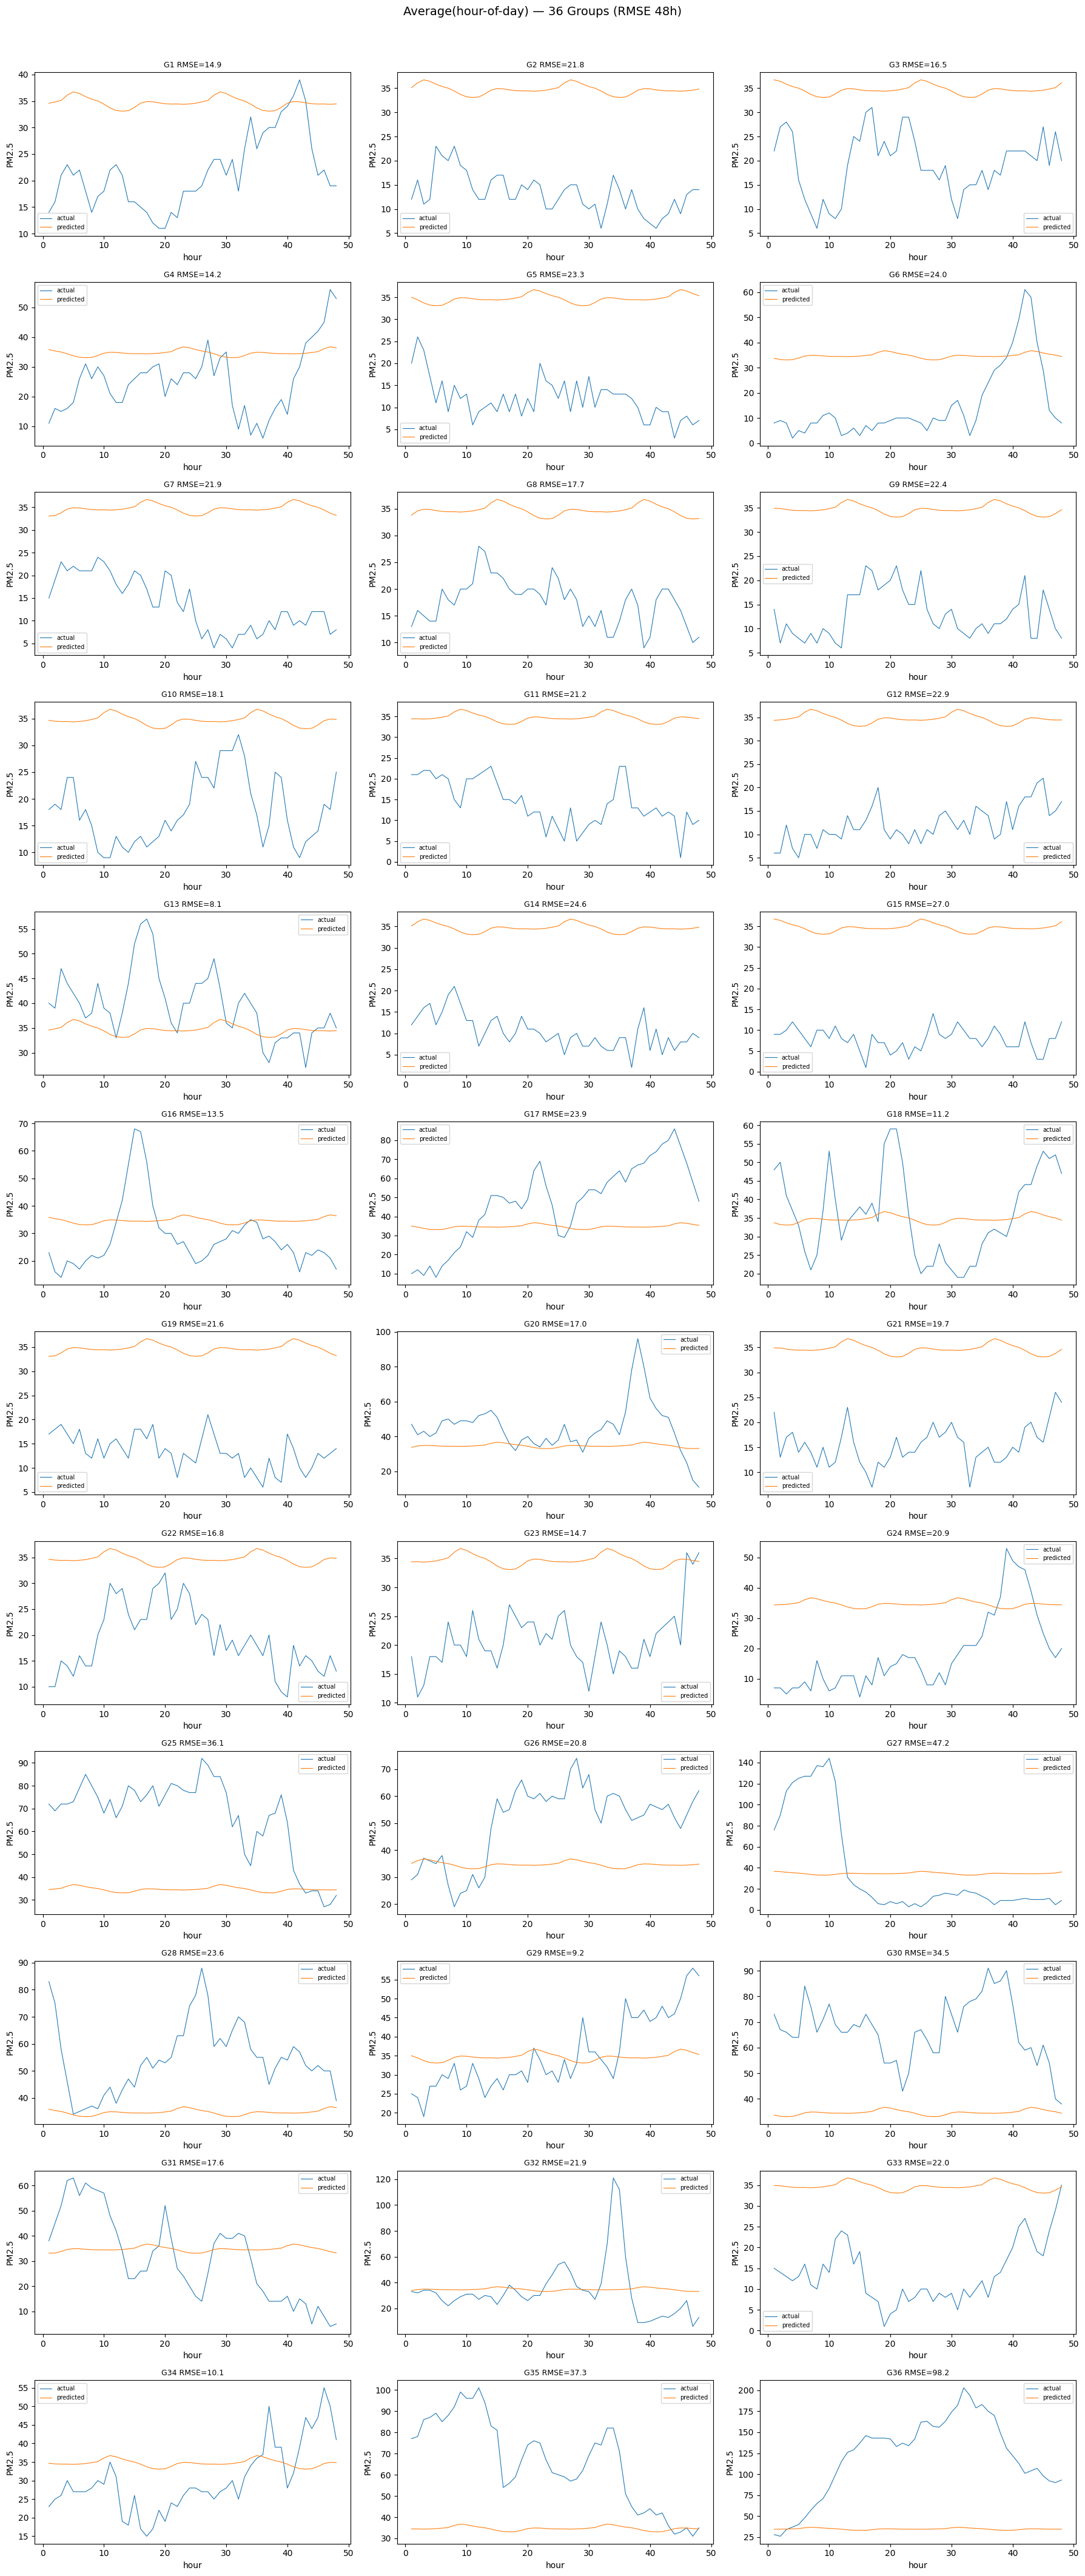


=== 36 组 RMSE 汇总 (48h | 24h) ===
  G 1:  14.87 |  18.08
  G 2:  21.80 |  19.78
  G 3:  16.51 |  16.21
  G 4:  14.22 |  12.59
  G 5:  23.29 |  21.86
  G 6:  24.04 |  27.44
  G 7:  21.92 |  16.30
  G 8:  17.67 |  15.57
  G 9:  22.36 |  21.81
  G10:  18.10 |  20.33
  G11:  21.22 |  18.11
  G12:  22.86 |  24.62
  G13:   8.08 |  10.04
  G14:  24.59 |  22.27
  G15:  26.96 |  27.29
  G16:  13.55 |  15.76
  G17:  23.94 |  17.65
  G18:  11.22 |  11.29
  G19:  21.61 |  20.02
  G20:  17.01 |  10.98
  G21:  19.71 |  20.73
  G22:  16.77 |  14.64
  G23:  14.72 |  15.06
  G24:  20.93 |  24.57
  G25:  36.12 |  40.81
  G26:  20.77 |  17.13
  G27:  47.18 |  62.22
  G28:  23.61 |  20.29
  G29:   9.24 |   6.95
  G30:  34.47 |  32.31
  G31:  17.55 |  16.09
  G32:  21.92 |   6.68
  G33:  21.96 |  22.90
  G34:  10.06 |  11.00
  G35:  37.27 |  47.13
  G36:  98.25 |  77.82

平均 RMSE(48h) = 23.23 | 参考 RMSE(24h) = 22.34


In [3]:
# ============================================================
# 36 组评估: 每组 24h 上下文 + 48h 预测, RMSE (ug/m3)
# 基线1: 按"一天各小时"的训练集均值 (逐小时气候)
# 同时报告 48h RMSE 与前 24h RMSE (参考)
# ============================================================
N_GROUPS, N_CTX, N_PRED = 36, 24, 48
STRIDE = (len(df_te) - N_CTX - N_PRED) // (N_GROUPS - 1)
pm_te = df_te['pm_ave'].values

rmses, rmses24 = [], []
fig, axes = plt.subplots(12, 3, figsize=(18, 42)); axes = axes.flatten()
for g in range(N_GROUPS):
    s = g * STRIDE
    hours = df_te.index[s+N_CTX:s+N_CTX+N_PRED].hour
    preds = hours.map(hourly_baseline).values
    actual = pm_te[s+N_CTX:s+N_CTX+N_PRED]
    err2 = (preds - actual) ** 2
    rmses.append(np.sqrt(err2.mean()))          # 48h RMSE
    rmses24.append(np.sqrt(err2[:24].mean()))   # 前 24h RMSE (参考)
    ax = axes[g]; h = np.arange(1, N_PRED+1)
    ax.plot(h, actual, lw=0.8, label='actual')
    ax.plot(h, preds, lw=0.8, label='predicted')
    ax.set_title(f'G{g+1} RMSE={rmses[-1]:.1f}', fontsize=9)
    ax.legend(fontsize=7); ax.set_xlabel('hour'); ax.set_ylabel('PM2.5')
plt.suptitle(f'Average(hour-of-day) — {N_GROUPS} Groups (RMSE 48h)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
rmses = np.array(rmses); rmses24 = np.array(rmses24)
print(f'\n=== {N_GROUPS} 组 RMSE 汇总 (48h | 24h) ===')
for g in range(N_GROUPS): print(f'  G{g+1:2d}: {rmses[g]:6.2f} | {rmses24[g]:6.2f}')
print(f'\n平均 RMSE(48h) = {rmses.mean():.2f} | 参考 RMSE(24h) = {rmses24.mean():.2f}')

训练集全体均值 = 34.69 ug/m3


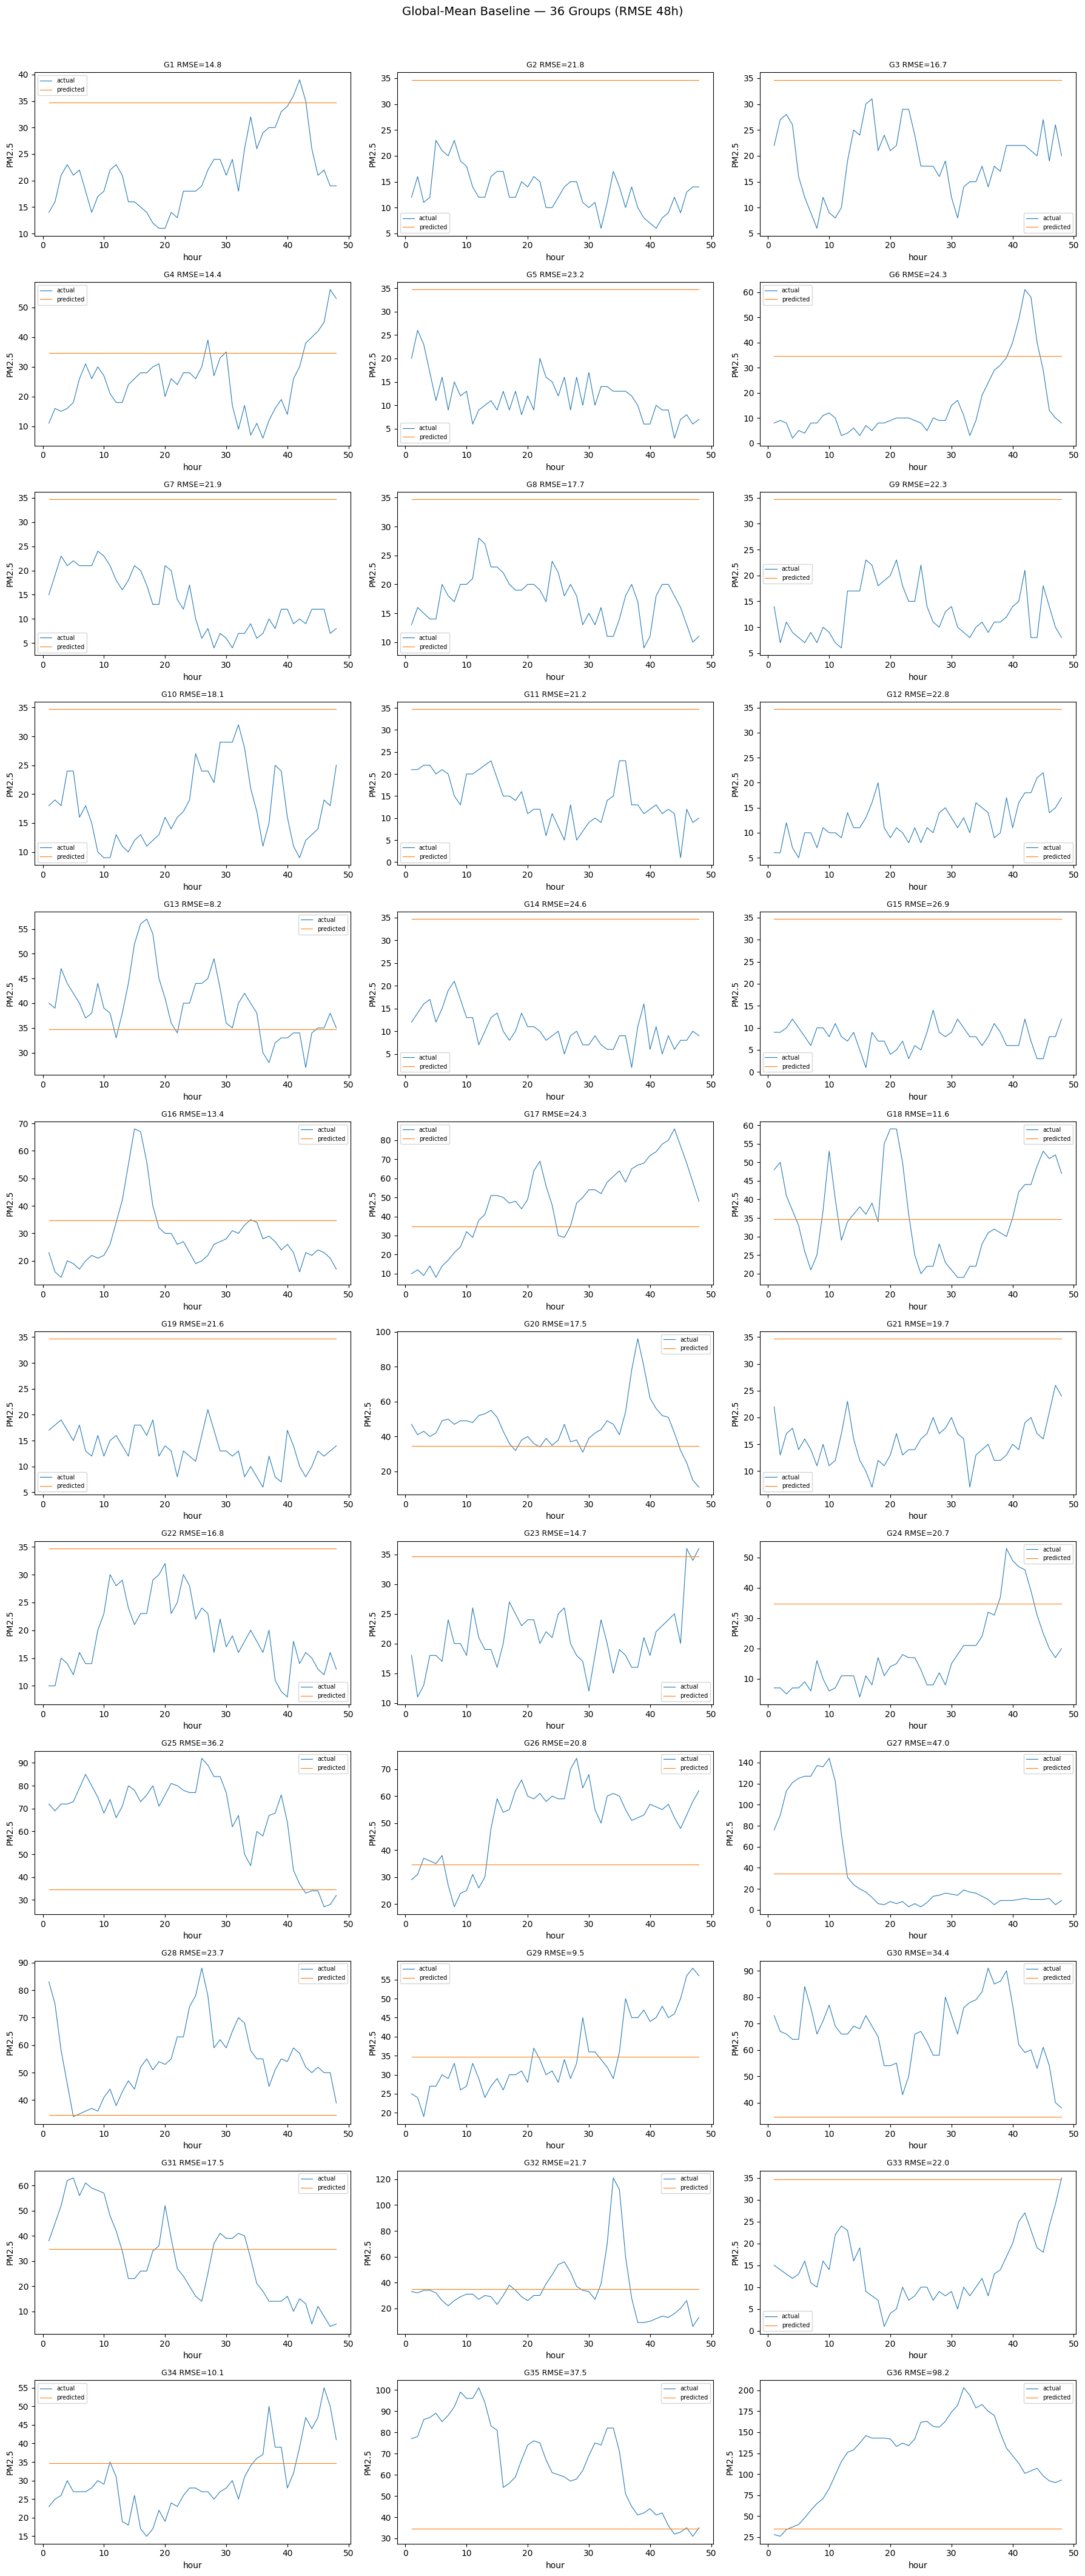


=== 常数(均值)基线 36 组 (48h | 24h) ===
  G 1:  14.80 |  18.07
  G 2:  21.78 |  19.77
  G 3:  16.65 |  16.46
  G 4:  14.41 |  12.46
  G 5:  23.22 |  21.83
  G 6:  24.26 |  27.45
  G 7:  21.91 |  16.26
  G 8:  17.68 |  15.60
  G 9:  22.32 |  21.75
  G10:  18.08 |  20.24
  G11:  21.23 |  18.10
  G12:  22.82 |  24.57
  G13:   8.24 |  10.06
  G14:  24.60 |  22.30
  G15:  26.95 |  27.27
  G16:  13.40 |  15.70
  G17:  24.31 |  18.33
  G18:  11.62 |  11.50
  G19:  21.58 |  20.01
  G20:  17.47 |  11.13
  G21:  19.66 |  20.75
  G22:  16.77 |  14.64
  G23:  14.66 |  15.01
  G24:  20.74 |  24.56
  G25:  36.20 |  40.82
  G26:  20.85 |  17.17
  G27:  46.99 |  61.98
  G28:  23.75 |  20.75
  G29:   9.51 |   7.14
  G30:  34.36 |  32.19
  G31:  17.47 |  15.95
  G32:  21.75 |   6.36
  G33:  21.99 |  23.06
  G34:  10.13 |  11.20
  G35:  37.53 |  47.33
  G36:  98.22 |  77.54

平均 RMSE(48h) = 23.27 | 参考 RMSE(24h) = 22.37


In [4]:
# ============================================================
# 基线2: 常数预测 = 训练集"所有数据"的单一平均值 (最朴素基线)
# 每个未来时刻的预测值恒等于该均值; 报告 48h 与 24h RMSE
# ============================================================
global_mean = df_tr['pm_ave'].mean()
print(f'训练集全体均值 = {global_mean:.2f} ug/m3')

rmses, rmses24 = [], []
fig, axes = plt.subplots(12, 3, figsize=(18, 42)); axes = axes.flatten()
for g in range(N_GROUPS):
    s = g * STRIDE
    preds = np.full(N_PRED, global_mean)        # 常数预测
    actual = pm_te[s+N_CTX:s+N_CTX+N_PRED]
    err2 = (preds - actual) ** 2
    rmses.append(np.sqrt(err2.mean()))
    rmses24.append(np.sqrt(err2[:24].mean()))
    ax = axes[g]; h = np.arange(1, N_PRED+1)
    ax.plot(h, actual, lw=0.8, label='actual')
    ax.plot(h, preds, lw=0.8, label='predicted')
    ax.set_title(f'G{g+1} RMSE={rmses[-1]:.1f}', fontsize=9)
    ax.legend(fontsize=7); ax.set_xlabel('hour'); ax.set_ylabel('PM2.5')
plt.suptitle(f'Global-Mean Baseline — {N_GROUPS} Groups (RMSE 48h)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
rmses = np.array(rmses); rmses24 = np.array(rmses24)
print(f'\n=== 常数(均值)基线 {N_GROUPS} 组 (48h | 24h) ===')
for g in range(N_GROUPS): print(f'  G{g+1:2d}: {rmses[g]:6.2f} | {rmses24[g]:6.2f}')
print(f'\n平均 RMSE(48h) = {rmses.mean():.2f} | 参考 RMSE(24h) = {rmses24.mean():.2f}')

持久性基线: 未来48h全部用最近一小时观测值常数外推



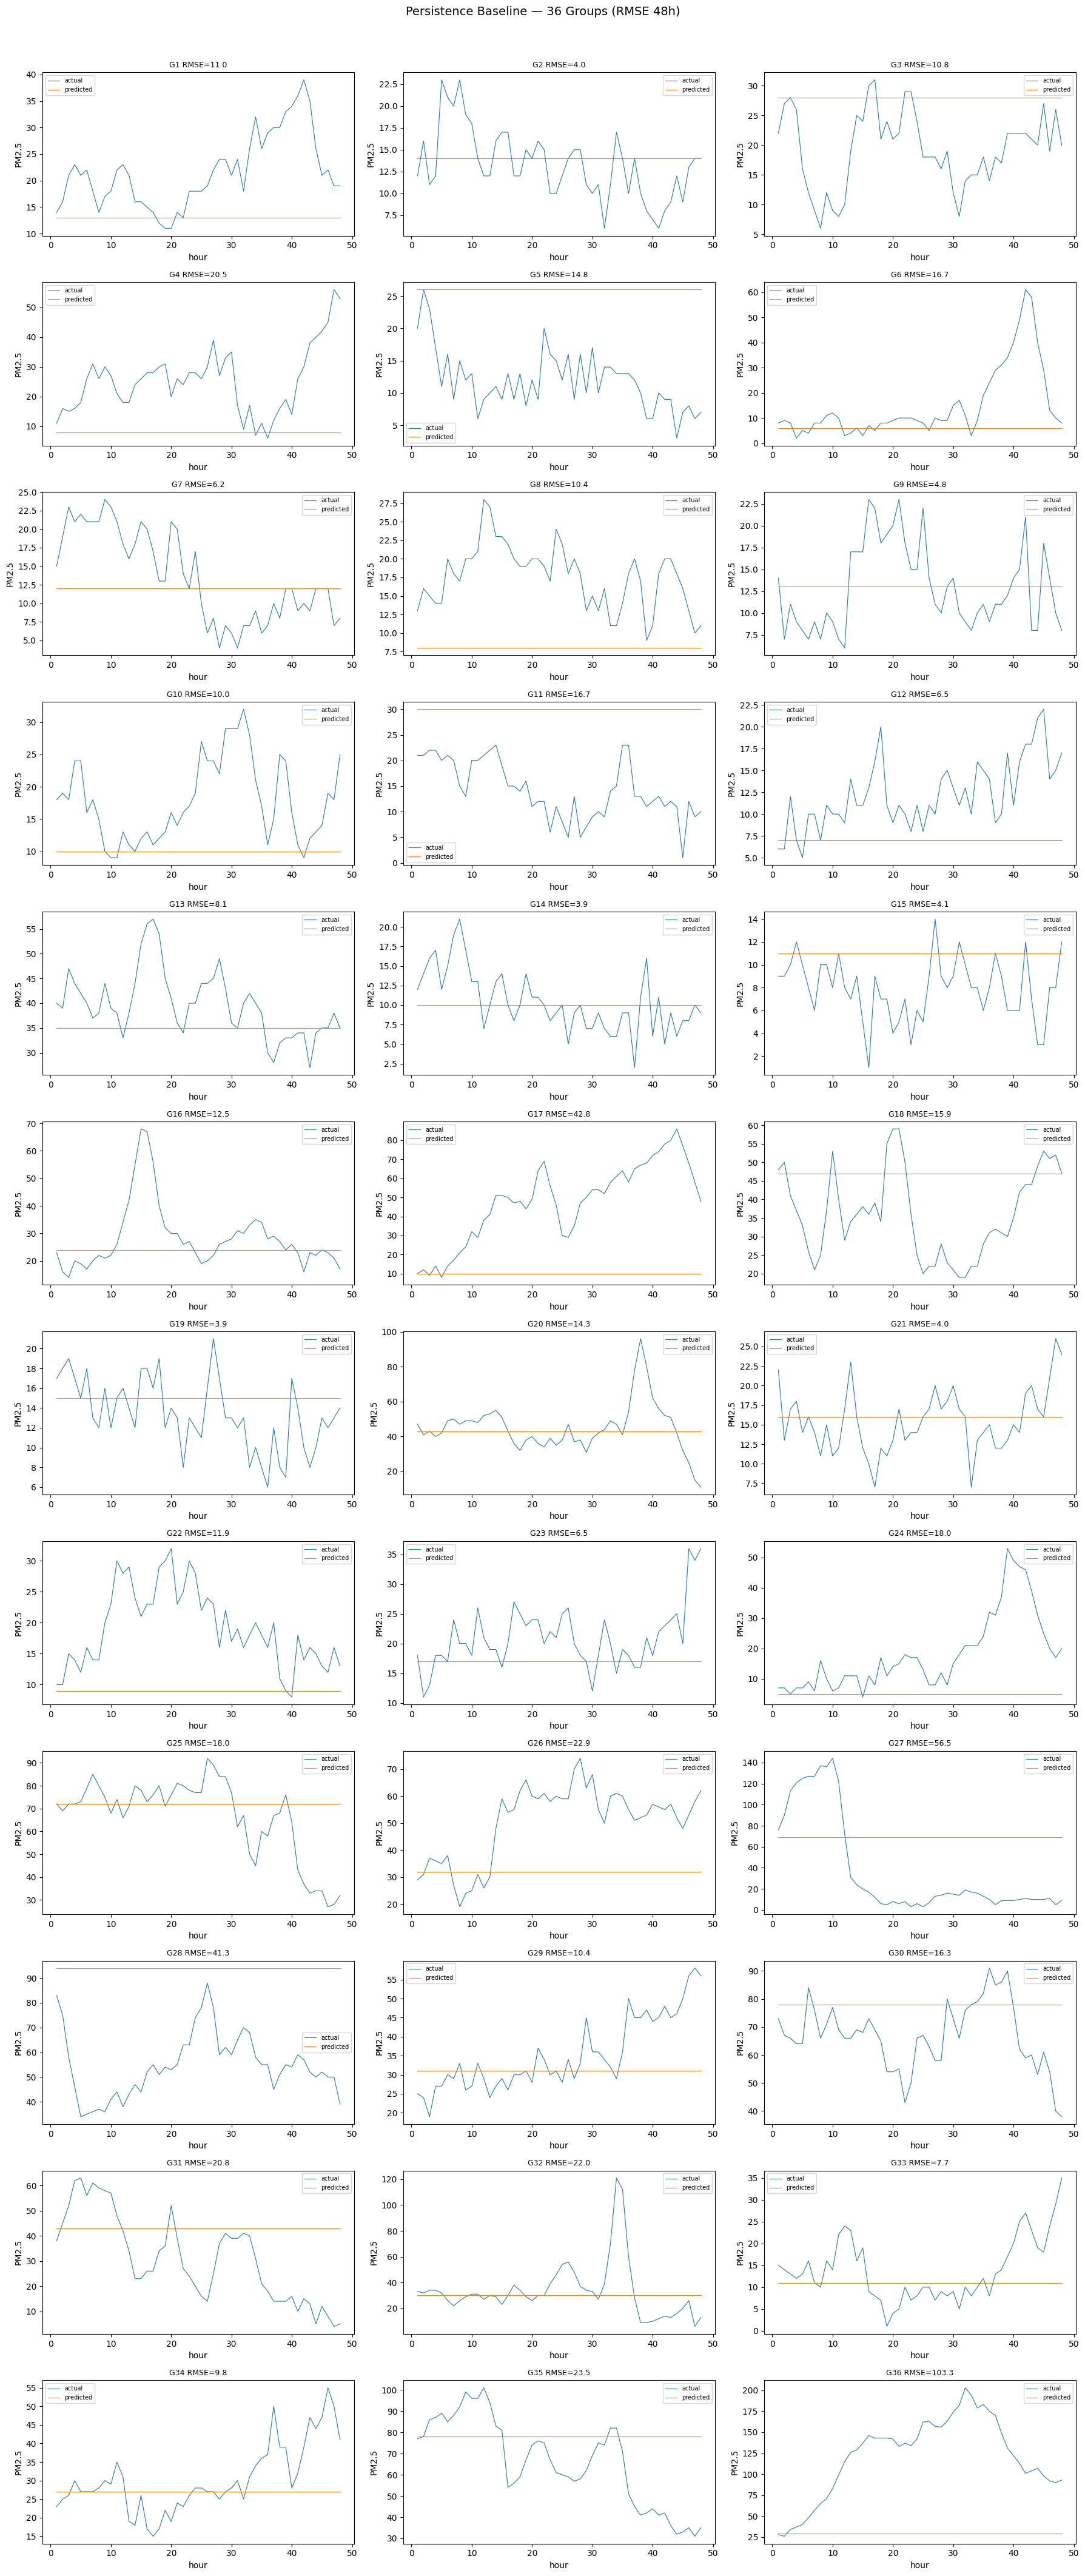


=== 持久性基线 36 组 (48h | 24h) ===
  G 1:  10.95 |   5.45
  G 2:   4.03 |   4.01
  G 3:  10.76 |  11.02
  G 4:  20.45 |  16.58
  G 5:  14.80 |  13.51
  G 6:  16.72 |   3.03
  G 7:   6.18 |   7.59
  G 8:  10.42 |  12.13
  G 9:   4.82 |   5.60
  G10:   9.95 |   6.40
  G11:  16.75 |  13.61
  G12:   6.51 |   4.64
  G13:   8.05 |   9.82
  G14:   3.88 |   4.40
  G15:   4.11 |   4.32
  G16:  12.53 |  16.95
  G17:  42.78 |  31.13
  G18:  15.95 |  13.14
  G19:   3.85 |   2.79
  G20:  14.29 |   6.55
  G21:   4.01 |   3.96
  G22:  11.93 |  14.54
  G23:   6.53 |   4.94
  G24:  18.05 |   6.94
  G25:  18.04 |   5.63
  G26:  22.94 |  18.61
  G27:  56.49 |  54.84
  G28:  41.31 |  45.26
  G29:  10.41 |   4.43
  G30:  16.34 |  15.24
  G31:  20.79 |  14.29
  G32:  21.99 |   5.17
  G33:   7.71 |   5.98
  G34:   9.77 |   5.52
  G35:  23.53 |  13.69
  G36: 103.26 |  82.27

平均 RMSE(48h) = 17.52 | 参考 RMSE(24h) = 13.72


In [5]:
# ============================================================
# 基线3: 持久性预测 (Persistence) — 未来48h常数等于"最近一小时"观测值
# 最经典的时间序列朴素基线: 明天跟今天一样; 报告 48h 与 24h RMSE
# ============================================================
print(f'持久性基线: 未来48h全部用最近一小时观测值常数外推\n')

rmses, rmses24 = [], []
fig, axes = plt.subplots(12, 3, figsize=(18, 42)); axes = axes.flatten()
for g in range(N_GROUPS):
    s = g * STRIDE
    last_known = pm_te[s + N_CTX - 1]              # 上下文最后一小时 (最近观测)
    preds = np.full(N_PRED, last_known)             # 常数预测
    actual = pm_te[s + N_CTX:s + N_CTX + N_PRED]
    err2 = (preds - actual) ** 2
    rmses.append(np.sqrt(err2.mean()))              # 48h RMSE
    rmses24.append(np.sqrt(err2[:24].mean()))       # 前 24h RMSE (参考)
    ax = axes[g]; h = np.arange(1, N_PRED + 1)
    ax.plot(h, actual, lw=0.8, label='actual')
    ax.plot(h, preds, lw=0.8, label='predicted')
    ax.set_title(f'G{g+1} RMSE={rmses[-1]:.1f}', fontsize=9)
    ax.legend(fontsize=7); ax.set_xlabel('hour'); ax.set_ylabel('PM2.5')
plt.suptitle(f'Persistence Baseline — {N_GROUPS} Groups (RMSE 48h)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
rmses = np.array(rmses); rmses24 = np.array(rmses24)
print(f'\n=== 持久性基线 {N_GROUPS} 组 (48h | 24h) ===')
for g in range(N_GROUPS): print(f'  G{g+1:2d}: {rmses[g]:6.2f} | {rmses24[g]:6.2f}')
print(f'\n平均 RMSE(48h) = {rmses.mean():.2f} | 参考 RMSE(24h) = {rmses24.mean():.2f}')